In [2]:
import os
import pickle
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
import functools
import sys

import jax
from jax import config

config.update("jax_enable_x64", True)

import jax.numpy as jnp

os.getcwd()
sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../"))
sys.path.append(os.path.abspath("../../"))

import yancc

os.getcwd()

'/home/fouriest/Work/yancc/publications'

In [3]:
from yancc.field import Field
from yancc.solve import solve_dke
from yancc.species import LocalMaxwellian
from yancc.velocity_grids import (
    MaxwellSpeedGrid,
    UniformPitchAngleGrid,
)

In [5]:
path = "./20251212-01-sfincs_for_yancc_benchmarks/20251212-01_sfincs_yancc_benchmark_NCSX_1species_collisionality_scan.txt"
sfincs_data = np.loadtxt(path, skiprows=1)
sfincs_data = {
    "nhat": sfincs_data[:, 0],
    "FSABflow": sfincs_data[:, 1],
    "particle_flux": sfincs_data[:, 2],
    "heat_flux": sfincs_data[:, 3],
    "energy_source": sfincs_data[:, 4],
}

In [6]:
base_path = (
    "./20251212-01-sfincs_for_yancc_benchmarks/20251212-01-030_collisionality_scan/"
)
sfincs_times = []
for i in range(31):
    files = os.listdir(base_path + f"{i:02d}/")
    f = [x for x in files if x.startswith("slurm")]
    lines = open(base_path + f"{i:02d}/" + f[0]).readlines()
    time_line = [l for l in lines if "Done with the main solve.  Time to solve:" in l][
        0
    ]
    time_ = float(time_line.split()[-2])
    sfincs_times.append(time_)
sfincs_times = np.array(sfincs_times)

# Resolution from sfincs

In [13]:
rho = 0.5
# hydrogen ion charge and mass (no electrons)
# n = 1.5e20 / m^3 * factor
# dn/dr = -0.4e20 / m^4 * factor
# where "factor" ranges from 0.1 to 100
# T = 0.8 keV
# dT/dr = -2.0 keV/m
# Er = -1 kV/m
# full Fokker-Planck collision operator with full trajectories.
nt = 43
nz = 65
na = 121
nx = 7
# The collisionality was set using ln(Lambda) = 17.

In [14]:
field = Field.from_vmec("../tests/data/wout_NCSX.nc", rho, nt, nz)
pitchgrid = UniformPitchAngleGrid(na)
speedgrid = MaxwellSpeedGrid(nx)

In [7]:
species = [
    LocalMaxwellian(
        yancc.species.Hydrogen,
        0.8e3,
        1.5e20 * nhat / 1.5,
        -2e3 * field.a_minor,
        -0.4e20 * field.a_minor * nhat / 1.5,
    )
    for nhat in sfincs_data["nhat"]
]
nustars = np.array([yancc.species.nustar(spec, field, 1.0) for spec in species])

In [8]:
nustars

array([0.00518575, 0.00648569, 0.00811114, 0.01014352, 0.01268458,
       0.01586147, 0.01983312, 0.02479811, 0.03100455, 0.03876249,
       0.04845926, 0.06057878, 0.07572558, 0.09465482, 0.11830976,
       0.14786855, 0.18480261, 0.23094954, 0.28860411, 0.36063173,
       0.45061021, 0.56300651, 0.70339736, 0.87874443, 1.0977377 ,
       1.37122371, 1.71273975, 2.13918005, 2.67162669, 3.33638556,
       4.16627818])

In [9]:
solve_dke_jit = jax.jit(functools.partial(solve_dke, verbose=2, print_every=10))

species = [
    LocalMaxwellian(
        yancc.species.Hydrogen,
        0.8e3,
        1.5e20 * 1 / 1.5,
        -2e3 * field.a_minor,
        -0.4e20 * field.a_minor * 1 / 1.5,
    )
]
solve_dke_compiled = (
    solve_dke_jit.trace(
        field,
        pitchgrid,
        speedgrid,
        species,
        -1 * field.a_minor * 1000,
        rtol=1e-7,
        coulomb_log=17,
    )
    .lower()
    .compile()
)

In [10]:
print(solve_dke_compiled.cost_analysis())

{'utilization322{}': 8.0, 'utilization504{}': 8.0, 'utilization252{}': 16.0, 'bytes accessed3{}': 11709553664.0, 'utilization134{}': 36.0, 'utilization104{}': 48.0, 'utilization121{}': 36.0, 'utilization439{}': 8.0, 'utilization337{}': 8.0, 'bytes accessed37{}': 25088.0, 'utilization214{}': 24.0, 'utilization460{}': 8.0, 'utilization226{}': 24.0, 'utilization378{}': 8.0, 'utilization278{}': 12.0, 'utilization69{}': 56.0, 'utilization0{}': 24363.98828125, 'utilization287{}': 12.0, 'utilization122{}': 36.0, 'utilization4{}': 1843.0, 'utilization49{}': 61.0, 'utilization258{}': 16.0, 'utilization168{}': 24.0, 'utilization264{}': 16.0, 'bytes accessedout{35}': 16.0, 'utilization190{}': 24.0, 'utilization381{}': 8.0, 'utilization401{}': 8.0, 'utilization344{}': 8.0, 'utilization27{}': 103.0, 'utilization29{}': 102.0, 'bytes accessedout{4}': 58587028.0, 'utilization389{}': 8.0, 'utilization260{}': 16.0, 'utilization143{}': 32.0, 'utilization280{}': 12.0, 'utilization92{}': 52.0, 'bytes acces

In [11]:
print(solve_dke_compiled.memory_analysis())

CompiledMemoryStats(generated_code_size_in_bytes=7711036, argument_size_in_bytes=231600, output_size_in_bytes=416888801, alias_size_in_bytes=0, temp_size_in_bytes=6444026496, host_generated_code_size_in_bytes=0, host_argument_size_in_bytes=0, host_output_size_in_bytes=0, host_alias_size_in_bytes=0, host_temp_size_in_bytes=0)


In [12]:
print(solve_dke_compiled.memory_analysis().temp_size_in_bytes / 1e9)

6.444026496


In [13]:
yancc_sols = []
yancc_infos1 = []
yancc_times1 = []
nustars = []

for nhat in sfincs_data["nhat"]:
    t0 = time.perf_counter()
    print("nHat:", nhat)
    species = [
        LocalMaxwellian(
            yancc.species.Hydrogen,
            0.8e3,
            1.5e20 * nhat / 1.5,
            -2e3 * field.a_minor,
            -0.4e20 * field.a_minor * nhat / 1.5,
        )
    ]
    nustars.append(yancc.species.nustar(species[0], field, x=1))
    sol, info = solve_dke_compiled(
        field,
        pitchgrid,
        speedgrid,
        species,
        -1 * field.a_minor * 1000,
        rtol=1e-7,
        coulomb_log=17,
    )
    del info["U"]
    del info["C"]
    yancc_sols.append(jax.block_until_ready(sol))
    yancc_infos1.append(info)
    t1 = time.perf_counter()
    yancc_times1.append(t1 - t0)
    print("TIME:", t1 - t0)

nHat: 0.15
Field info (source: vmec):
    ρ         =  0.500              ι         = -4.689e-01
    <B>       =  1.538e+00 T        δ_B       =  4.857e-02
    Bmax/Bmin =  1.183e+00          f_trapped =  3.902e-01
    I         = -4.318e-03 T·m      G         =  2.325e+00 T·m
<E||B> :  0.00e+00 (V*T/m)
Eᵨ = -∂Φ /∂ρ: -3.23e+02 (V)
Species  0:  m= 1.00e+00 (mₚ)      q= 1.00e+00 (qₚ)
             n= 1.50e+19 (m⁻³)  a/Lₙ= 8.60e-02
             T= 8.00e+02 (eV)   a/Lᴛ= 8.07e-01  
             ν* (x=6.37e-02):  2.318e+01
             ν* (x=1.00e+00):  5.018e-03
             ν* (x=3.37e+00):  5.890e-05
E* (x=1.0): [-1.661e-03 ] (per species)
Mₚ (x=1.0): [-1.658e-02 ] (per species)
A₁: [ 1.527e+00 ] (per species)
A₂: [-8.066e-01 ] (per species)
A₃: [ 0.000e+00 ] (per species)
Grid 0: nx=   7, nα=  18, nθ=   6, nζ=  10, N=7,560
Grid 1: nx=   7, nα=  34, nθ=  12, nζ=  18, N=51,408
Grid 2: nx=   7, nα=  64, nθ=  23, nζ=  35, N=360,640
Grid 3: nx=   7, nα= 121, nθ=  43, nζ=  65, N=2,367,365
GCROT

In [14]:
data = {
    "yancc_sols": yancc_sols,
    "yancc_infos": yancc_infos1,
    "yancc_times": np.array(yancc_times1),
    "sfincs_data": sfincs_data,
    "sfincs_times": sfincs_times,
    "nustars": nustars,
}
with open("benchmark_nhat_scan.pkl", "wb+") as f:
    pickle.dump(data, f)

In [7]:
with open("benchmark_nhat_scan.pkl", "rb") as f:
    data = pickle.load(f)

In [8]:
from matplotlib import rcParams

matplotlib.rcdefaults()
rcParams["font.family"] = "DejaVu Serif"
rcParams["mathtext.fontset"] = "cm"
rcParams["font.size"] = 10
rcParams["figure.facecolor"] = (1, 1, 1, 1)
rcParams["figure.figsize"] = (6, 4)
rcParams["lines.markersize"] = 4
rcParams["xtick.labelsize"] = 10
rcParams["ytick.labelsize"] = 10

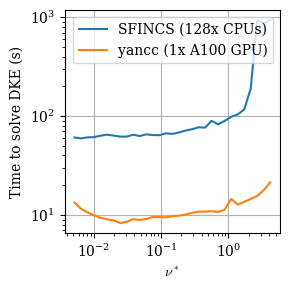

In [9]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.loglog(data["nustars"], data["sfincs_times"], label="SFINCS (128x CPUs)")
ax.loglog(data["nustars"], data["yancc_times"], label="yancc (1x A100 GPU)")
ax.legend()
ax.set_ylabel("Time to solve DKE (s)")
ax.set_xlabel("$\\nu^*$")
ax.grid(True)
fig.set_tight_layout(True)

In [9]:
fig.savefig("benchmark_nhat_scan_timing.pdf")
fig.savefig("benchmark_nhat_scan_timing.png")

(1, 100)

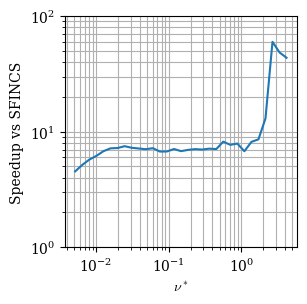

In [10]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.loglog(data["nustars"], data["sfincs_times"] / data["yancc_times"])
ax.set_ylabel("Speedup vs SFINCS")
ax.set_xlabel("$\\nu^*$")
ax.grid(True, "both")
ax.set_ylim(1, 100)

In [16]:
normalized_fluxes = {}
normalized_fluxes["FSABFlow"] = np.array(
    [sol.get("FSABFlow_sfincs") for sol in data["yancc_sols"]]
)
normalized_fluxes["particleFlux_vm_rN"] = np.array(
    [sol.get("particleFlux_vm_rN_sfincs") for sol in data["yancc_sols"]]
)
normalized_fluxes["heatFlux_vm_rN"] = np.array(
    [sol.get("heatFlux_vm_rN_sfincs") for sol in data["yancc_sols"]]
)

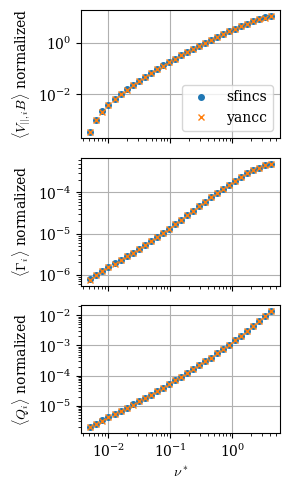

In [17]:
fig, ax = plt.subplots(3, 1, figsize=(3, 5), sharex=True)
ax[0].loglog(
    data["nustars"], -sfincs_data["FSABflow"], label="sfincs", marker="o", ls=""
)
ax[1].loglog(
    data["nustars"], sfincs_data["particle_flux"] / field.a_minor, marker="o", ls=""
)
ax[2].loglog(
    data["nustars"], sfincs_data["heat_flux"] / field.a_minor, marker="o", ls=""
)
ax[0].loglog(
    data["nustars"], -normalized_fluxes["FSABFlow"], label="yancc", marker="x", ls=""
)
ax[1].loglog(
    data["nustars"], normalized_fluxes["particleFlux_vm_rN"], marker="x", ls=""
)
ax[2].loglog(data["nustars"], normalized_fluxes["heatFlux_vm_rN"], marker="x", ls="")
ax[0].legend()
ax[0].grid(True)
ax[1].grid(True)
ax[2].grid(True)
ax[0].set_ylabel(r"$\langle V_{||,i}B \rangle$ normalized")
ax[1].set_ylabel(r"$\langle \Gamma_i \rangle$ normalized")
ax[2].set_ylabel(r"$\langle Q_i \rangle$ normalized")
ax[2].set_xlabel("$\\nu^*$")
fig.set_tight_layout(True)

In [22]:
fig.savefig("benchmark_nhat_scan_fluxes.pdf")
fig.savefig("benchmark_nhat_scan_fluxes.png")

In [18]:
yancc_fluxes = {}
yancc_fluxes["FSABFlow"] = np.array([sol.get("<V||B>") for sol in data["yancc_sols"]])
yancc_fluxes["particleFlux_vm_rN"] = np.array(
    [sol.get("<particle_flux>") for sol in data["yancc_sols"]]
)
yancc_fluxes["heatFlux_vm_rN"] = np.array(
    [sol.get("<heat_flux>") for sol in data["yancc_sols"]]
)

In [19]:
from scipy.constants import Boltzmann, proton_mass

JOULE_PER_EV = jnp.array(11606 * Boltzmann)


Rbar = 1.0
mbar = 1.0 * proton_mass
Tbar = 1e3 * JOULE_PER_EV
nbar = 1e20
vbar = jnp.sqrt(2 * Tbar / mbar)
Bbar = 1.0

species = [
    LocalMaxwellian(
        yancc.species.Hydrogen,
        0.8e3,
        1.5e20 * nhat / 1.5,
        -2e3 * field.a_minor,
        -0.4e20 * field.a_minor * nhat / 1.5,
    )
    for nhat in sfincs_data["nhat"]
]

density = np.array([sp.density for sp in species])

pfscale = Rbar / (nbar * vbar)
hfscale = Rbar / (nbar * vbar**3 * mbar)
vbscale = density / (vbar * Bbar * nbar)

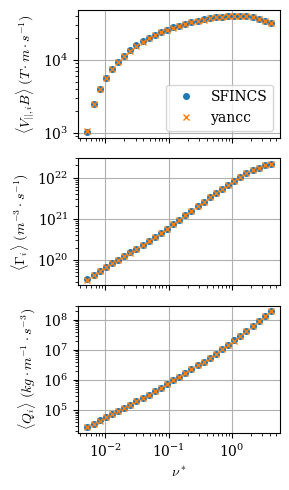

In [20]:
fig, ax = plt.subplots(3, 1, figsize=(3, 5), sharex=True)
ax[0].loglog(
    data["nustars"],
    -sfincs_data["FSABflow"] / vbscale,
    label="SFINCS",
    marker="o",
    ls="",
)
ax[1].loglog(
    data["nustars"],
    sfincs_data["particle_flux"] / field.a_minor / pfscale,
    marker="o",
    ls="",
)
ax[2].loglog(
    data["nustars"],
    sfincs_data["heat_flux"] / field.a_minor / hfscale,
    marker="o",
    ls="",
)
ax[0].loglog(
    data["nustars"], -yancc_fluxes["FSABFlow"], label="yancc", marker="x", ls=""
)
ax[1].loglog(data["nustars"], yancc_fluxes["particleFlux_vm_rN"], marker="x", ls="")
ax[2].loglog(data["nustars"], yancc_fluxes["heatFlux_vm_rN"], marker="x", ls="")
ax[0].legend()
ax[0].grid(True)
ax[1].grid(True)
ax[2].grid(True)
ax[0].set_ylabel(r"$\langle V_{||,i}B \rangle ~(T \cdot m \cdot s^{-1})$")
ax[1].set_ylabel(r"$\langle \Gamma_i \rangle ~(m^{-3} \cdot s^{-1})$")
ax[2].set_ylabel(r"$\langle Q_i \rangle ~(kg \cdot m^{-1} \cdot s^{-3})$")
ax[2].set_xlabel("$\\nu^*$")
fig.set_tight_layout(True)

In [26]:
fig.savefig("benchmark_nhat_scan_fluxes.pdf")
fig.savefig("benchmark_nhat_scan_fluxes.png")